# **Lab 2 – Tidying, Cleaning, Imputation, and Outlier Detection**

## Machine Learning Programming

This assignment continues the work started in **`week5Lab.ipynb`**.  
Open this notebook and complete the activities **in this notebook**, preserving the section order and the overall structure.

The purpose of this lab is to practice the data-preprocessing work that normally takes place before machine learning: reshaping data, cleaning inconsistent values, handling missing data, detecting outliers, visualizing results, and explaining the decisions you make.

## **Assignment Overview**

### Purpose
By the end of this lab, you should be able to take several imperfect datasets and make them more suitable for analysis and later machine-learning work.

### Learning Outcomes
You will practice how to:

- inspect the shape, columns, data types, and quality of a dataset;
- distinguish **wide** and **long/tidy** data;
- reshape data with `pd.melt()` or `DataFrame.melt()`;
- clean strings using Pandas string methods;
- identify, quantify, drop, and impute missing values;
- compare mean, median, mode, and `SimpleImputer` approaches;
- identify outliers visually with box plots and scatter plots;
- identify outliers statistically using **Z-Scores** and **IQR**;
- justify preprocessing decisions using evidence from the data;
- document a reproducible Python data-processing workflow.

### Estimated Completion Time
Approximately **2.5–3.5 hours**, depending on your Python experience.

## **Submission and Project Structure**

Keep the project organized so another person can reproduce your work.

Recommended structure:

```text
project/
├── week5Lab.ipynb
├── README.md
├── requirements.txt
├── .gitignore
└── data/
    ├── pew-raw.csv
    ├── billboard.csv
    ├── cars.csv
    └── diabetes.csv
```

A clearly named equivalent data folder such as `CSVs/` or `datasets/` is also acceptable if all notebook paths are updated consistently.

### Required submission artifacts

- `week5Lab.ipynb` containing **all four completed sections**
- `README.md` with at least 1–2 meaningful sentences describing the lab and how to run it
- `requirements.txt` containing the packages required to reproduce the environment
- `.gitignore`
- all required data files inside a clearly named data folder

**Important:** Use relative paths such as `./data/cars.csv`. Do not use absolute paths from your own computer.

**Environment practice:** Use `requirements.txt` to define the environment. Do not add `!pip install ...` cells to the notebook when a requirements file is provided.

## **Before You Begin**

Use the following libraries where appropriate:

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `scikit-learn`

Run the import cell below before beginning the exercises.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

# Optional display settings
pd.set_option("display.max_columns", None)

## **General Expectations**

For every section:

1. Write the required Python code.
2. Display enough output to demonstrate that the code works.
3. Add short Markdown explanations in your own words.
4. Label plots clearly with a title and axis labels.
5. Explain what the output means instead of only producing it.
6. Preserve the required section headings so the notebook is easy to follow.
7. Before submitting, restart the kernel and use **Run All** to confirm the notebook executes from beginning to end.

# **Section 1 – PEW Research Dataset**

## **Learning Topic: Data Tidying and Reshaping**

A dataset is commonly described as **tidy** when:

1. each variable forms a column;
2. each observation forms a row; and
3. each type of observational unit forms a table.

The PEW dataset represents counts for religions across income ranges. In its original form, income values appear as column headings. You will reshape the dataset from **wide** format to **long/tidy** format using `melt()`.

### Required concepts
- dataset inspection
- wide versus long data
- identifier variables
- measured variables
- `pd.melt()` or `DataFrame.melt()`
- visualization after reshaping

## **Getting the PEW Dataset from the Internet**

For this lab, use the small **PEW religion-and-income dataset** commonly used to demonstrate tidy-data principles. This is the dataset whose first column is `religion` and whose remaining columns are income ranges such as `<$10k`, `$10-20k`, and `$20-30k`.

### Recommended method — download in your browser

1. Open the dataset in a browser:
   `https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv`
2. Save the file as **`pew-raw.csv`**.
3. Create a folder named **`data`** in the same project folder as this notebook if it does not already exist.
4. Move `pew-raw.csv` into the `data` folder.
5. Confirm that your project contains:

```text
project/
├── week5Lab.ipynb
└── data/
    └── pew-raw.csv
```

6. Load the local copy with:

```python
df_pew = pd.read_csv("./data/pew-raw.csv")
```

### Optional Python-assisted download

The following is an example only. You may use it once to obtain the dataset, but your submitted analysis should subsequently read the **local copy** from `./data/`.

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv"
df_pew = pd.read_csv(url)
df_pew.to_csv("./data/pew-raw.csv", index=False)
```

### Verify before continuing

After loading the file, check that the dataframe contains a `religion` column and multiple income-range columns. If it does not, stop and verify that you downloaded the correct dataset.

> **Good reproducibility practice:** Do not depend on the Internet every time the notebook runs. Download the dataset once, store it in the project's `data/` folder, commit the permitted data file to your repository, and use a relative path in the notebook.

### Data Acquisition: Python-Assisted Download
For this dataset, I chose to use the Python-assisted download method rather than a manual browser download. This approach ensures that the data acquisition step is fully reproducible and automated within the notebook environment, eliminating manual steps and reducing the chance of human error when setting up the project on a new machine.

In [2]:
# One-time setup: Download all required datasets
from pathlib import Path
import pandas as pd


# 1. PEW Dataset
url_pew = "https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv"
df_pew = pd.read_csv(url_pew)
df_pew.to_csv("../data/pew-raw.csv", index=False)
print(f"✅ PEW dataset saved: {df_pew.shape}")

# 2. Billboard Dataset
url_billboard = "https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv"
df_billboard = pd.read_csv(url_billboard)
df_billboard.to_csv("../data/billboard.csv", index=False)
print(f"✅ Billboard dataset saved: {df_billboard.shape}")

# 3. Auto MPG (Cars) Dataset
url_cars = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
             'acceleration', 'model_year', 'origin', 'car_name']
cars = pd.read_csv(url_cars, sep=r'\s+', header=None, names=col_names, na_values='?')
cars.to_csv("../data/cars.csv", index=False)
print(f"✅ Cars dataset saved: {cars.shape}")

# 4. Diabetes Dataset
url_diabetes = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes = pd.read_csv(url_diabetes)
diabetes.to_csv("../data/diabetes.csv", index=False)
print(f"✅ Diabetes dataset saved: {diabetes.shape}")

print("\n🎉 All datasets downloaded to ../data/")

✅ PEW dataset saved: (10, 7)
✅ Billboard dataset saved: (317, 77)
✅ Cars dataset saved: (398, 9)
✅ Diabetes dataset saved: (768, 9)

🎉 All datasets downloaded to ../data/


### **Task 1.1 – Load and Inspect the Dataset**

1. Load the PEW dataset from your data folder.
2. Display its shape.
3. Display its column names.
4. Display several rows using `head()`, `loc`, `iloc`, or `tail()`.
5. Identify the column that should remain the identifier variable.

In [3]:
# Task 1.1 – Load and Inspect the Dataset
df_pew = pd.read_csv("../data/pew-raw.csv")

print(f"Shape: {df_pew.shape}")
print(f"\nColumns: {df_pew.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df_pew.head())

# The 'religion' column is the identifier variable — it uniquely identifies each row
# and should remain fixed while we reshape the income columns.
print("\nIdentifier column: 'religion'")

Shape: (10, 7)

Columns: ['religion', ' <$10k', ' $10-20k', '$20-30k', '$30-40k', ' $40-50k', '$50-75k']

First 5 rows:


,religion,<$10k,$10-20k,$20-30k,$30-40k,$40-50k,$50-75k
0,Agnostic,27,34,60,81,76,137
1,Atheist,12,27,37,52,35,70
2,Buddhist,27,21,30,34,33,58
3,Catholic,418,617,732,670,638,1116
4,Dont know/refused,15,14,15,11,10,35



Identifier column: 'religion'


### **Task 1.2 – Explain the Problem**

In a Markdown cell below, answer:

- What is not tidy about the original PEW dataset?
- Which values are stored in column names?
- Which column should be treated as the identifier (`id_vars`)?

### Task 1.2 – Explain the Problem

**What is not tidy about the original PEW dataset?**
The original dataset violates the core tidy data principle that "each variable forms a column." The dataset is structured in a "wide" format, meaning the different categories of a single variable are spread horizontally across multiple column headers rather than being grouped together.

**Which values are stored in column names?**
The specific income ranges (e.g., `<$10k`, `$10-20k`, `$20-30k`, etc.) are stored as column names. In a tidy dataset, these should be treated as values within a single `income` column, with a corresponding `count` column for the measured data.

**Which column should be treated as the identifier (`id_vars`)?**
The `religion` column should be treated as the identifier variable (`id_vars`). It represents the core observational unit (the religious group) and must remain fixed while we reshape the income categories and respondent counts from columns into rows.

### **Task 1.3 – Reshape with `melt()`**

Use either of these valid Pandas forms:

```python
pd.melt(...)
```

or

```python
df.melt(...)
```

Your result should have meaningful names for the new variable and value columns, such as `income` and `count`.

### Task 1.3 – Reshape with `melt()`

To transform the dataset from wide to long format, we use `pd.melt()`. We keep `religion` as the identifier variable (`id_vars`) because it represents the core observational unit that must remain fixed. 

To ensure the resulting dataframe is self-explanatory and strictly adheres to tidy data principles, we explicitly assign meaningful names to the newly created columns using `var_name='income'` and `value_name='count'`. This clearly distinguishes the measured variable (the income bracket) from the actual measured value (the respondent count), making the data much easier to query and visualize.

In [4]:
# Task 1.3 – Reshape the data from wide to long format using pd.melt()
# We keep 'religion' as the id_var and melt all income columns into two new columns:
# 'income' (the variable) and 'count' (the value)
df_pew_tidy = pd.melt(df_pew, id_vars='religion', var_name='income', value_name='count')

print(f"Reshaped from {df_pew.shape} to {df_pew_tidy.shape}")
display(df_pew_tidy.head(10))

Reshaped from (10, 7) to (60, 3)


,religion,income,count
0,Agnostic,<$10k,27
1,Atheist,<$10k,12
2,Buddhist,<$10k,27
3,Catholic,<$10k,418
4,Dont know/refused,<$10k,15
5,Evangelical Prot,<$10k,575
6,Hindu,<$10k,1
7,Historically Black Prot,<$10k,228
8,Jehovahs Witness,<$10k,20
9,Jewish,<$10k,19


### **Task 1.4 – Visualize the Tidy Data**

Create at least **one meaningful visualization** from the reshaped dataset.

Possible questions include:

- How do counts differ across income groups?
- How do selected religions compare across income groups?

Your plot must include a title and axis labels.

### Task 1.4 – Visualization Analysis

**How do counts differ across income groups?**
The visualization reveals that the distribution of respondents is heavily right-skewed. The vast majority of survey responses are concentrated in the lower-to-middle income brackets (from `<$10k` up to `$50-75k`). As the income brackets increase into the higher tiers (e.g., `$100-150k` and `>150k`), the total respondent counts drop off significantly. This indicates that the survey sample is not perfectly evenly distributed across economic demographics.

**How do selected religions compare across income groups?**
The data shows a clear dominance by a few major religious groups across almost all income levels. Specifically, **Evangelical Protestant** and **Mainline Protestant** consistently account for the highest volume of respondents in nearly every income bracket. In contrast, smaller religious affiliations (such as Buddhist, Jewish, or Hindu) show uniformly low counts across the board. Additionally, the **"Don't know/Refused"** category represents a surprisingly large portion of the data, particularly in the middle-to-higher income brackets, suggesting a notable rate of non-response or privacy preference among those demographics.

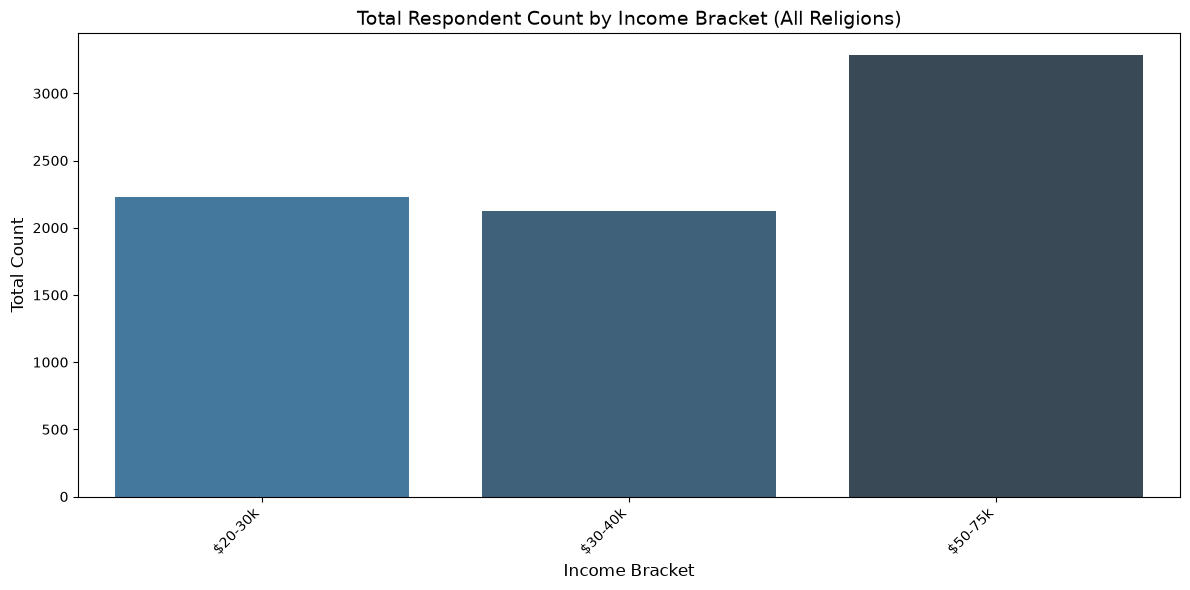

In [5]:
# Task 1.4 – Visualize the Tidy Data
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

# Calculate total count per income bracket
income_totals = df_pew_tidy.groupby('income')['count'].sum().reset_index()

# Define a logical order for income brackets
income_order = ['<$10k', '$10-20k', '$20-30k', '$30-40k', '$40-50k', 
                '$50-75k', '$75-100k', '$100-150k', '>150k', "Don't know/Refused"]

# Filter to only include brackets that actually exist in the data
income_order = [x for x in income_order if x in income_totals['income'].values]

# Plot using 'order' to sort the x-axis (fixes the Pandas Categorical warning)
# and 'hue' to satisfy the new Seaborn palette requirement
sns.barplot(data=income_totals, x='income', y='count', order=income_order, 
            hue='income', palette='Blues_d', legend=False, ax=ax)

ax.set_title('Total Respondent Count by Income Bracket (All Religions)', fontsize=14)
ax.set_xlabel('Income Bracket', fontsize=12)
ax.set_ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Task 1.5 – PEW Reflection**

Answer **all** questions briefly in your own words:

1. What was the main structural problem with the original dataset?
2. What does `id_vars` mean in `melt()`?
3. What information moved from columns into rows?
4. How did the number of rows change after reshaping, and why?
5. Why is the long format easier to analyze or visualize?
6. What did your visualization reveal?

### Task 1.5 – PEW Reflection

1. **What was the main structural problem with the original dataset?**  
   The original dataset was in a "wide" format, which violates the core tidy data principle that *each variable must form its own column*. Instead, the income brackets were stored as column headers, meaning the variable "income" was spread horizontally across multiple columns.

2. **What does `id_vars` mean in `melt()`?**  
   `id_vars` specifies the identifier variable(s) that represent the core observational unit (in this case, `religion`). These columns are kept fixed and are not unpivoted during the reshaping process.

3. **What information moved from columns into rows?**  
   The income bracket categories (e.g., `<$10k`, `$10-20k`) were moved from column headers into values within a new `income` column. Their corresponding respondent counts were moved into a new `count` column.

4. **How did the number of rows change after reshaping, and why?**  
   The number of rows increased significantly (multiplying by the number of income columns). This happens because `melt()` creates a new, separate row for every combination of the identifier (`religion`) and the measured variable (`income`), transforming one wide row into multiple long rows.

5. **Why is the long format easier to analyze or visualize?**  
   Long (tidy) format aligns perfectly with how data analysis and visualization libraries (like Pandas and Seaborn) are designed to work. It allows us to easily group, filter, or plot data by mapping specific columns (like `income` to the x-axis and `count` to the y-axis) without having to manually reference dozens of individual column headers.

6. **What did your visualization reveal?**  
   The bar chart revealed that the respondent distribution is heavily right-skewed, with the vast majority of counts concentrated in the lower-to-middle income brackets (up to `$50-75k`). It also highlighted that Evangelical and Mainline Protestants consistently represent the largest share of respondents across almost all income levels, while the "Don't know/Refused" category represents a surprisingly large portion of the higher income brackets.

# **Section 2 – Billboard Dataset**

## **Learning Topic: Advanced Data Tidying**

The Billboard dataset stores weekly song rankings across many week columns. You will reshape those columns into rows, clean the resulting week labels, convert ranking values to appropriate data types, handle missing values, and analyze ranking trends.

### Required concepts
- `pd.melt()` or `DataFrame.melt()`
- Pandas string methods such as:
  - `.str.replace()`
  - `.str.strip()`
  - `.str.extract()`
  - `.str.upper()`
  - `.str.lower()`
- numeric conversion
- missing-value handling
- dates / timedeltas where appropriate

## **Getting the Billboard Dataset from the Internet**

Use the **Billboard weekly ranking dataset** associated with the classic tidy-data example. The correct file contains song information plus many weekly ranking columns such as `1st week`, `2nd week`, etc. (column names can vary slightly between copies).

### Recommended method — download in your browser

1. Open this public copy of `billboard.csv`:
   `https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv`
2. Save the file as **`billboard.csv`**.
3. Place it inside your project's **`data`** folder.
4. Your project should now include:

```text
project/
├── week5Lab.ipynb
└── data/
    ├── pew-raw.csv
    └── billboard.csv
```

5. Load the local file. If ordinary UTF-8 decoding fails, try `encoding="unicode_escape"`:

```python
billboard = pd.read_csv("./data/billboard.csv", encoding="unicode_escape")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv"
billboard = pd.read_csv(url, encoding="unicode_escape")
billboard.to_csv("./data/billboard.csv", index=False)
```

### Verify before continuing

Inspect `billboard.columns`. You should see identifying information for songs/artists and a sequence of weekly ranking columns. Those repeated week columns are the columns you will later reshape with `melt()`.

> **Important:** Different online copies sometimes use slightly different column names. Do not blindly copy column names from an example. Inspect **your downloaded file** first and adapt your code accordingly.

### **Task 2.1 – Load and Inspect Billboard Data**

1. Load the Billboard dataset.
2. If normal UTF-8 decoding fails, try `encoding="unicode_escape"`.
3. Display its shape, columns, and first rows.
4. Identify the columns that represent weekly rankings.

In [6]:
# Load the Billboard dataset
# Note: encoding="unicode_escape" is sometimes needed for this specific dataset's formatting
billboard = pd.read_csv("../data/billboard.csv", encoding="unicode_escape")

print(f"Shape: {billboard.shape}")
print(f"\nColumns: {billboard.columns.tolist()[:10]}...") # Showing first 10 for brevity
print(f"\nData Types:\n{billboard.dtypes.value_counts()}")
display(billboard.head(3))

Shape: (317, 77)

Columns: ['artist', 'track', 'duration', 'genre', 'date entered', 'date peaked', 'weeks to peak', 'weeks on chart', 'worst position', 'best position']...

Data Types:
float64    64
int64       8
str         5
Name: count, dtype: int64


,artist,track,duration,genre,date entered,date peaked,weeks to peak,weeks on chart,worst position,best position,enter rank,exit rank,1st week,2nd week,3rd week,4th week,5th week,6th week,7th week,8th week,9th week,10th week,11th week,12th week,13th week,14th week,15th week,16th week,17th week,18th week,19th week,20th week,21st week,22nd week,23rd week,24th week,25th week,26th week,27th week,28th week,29th week,30th week,31st week,32nd week,33rd week,34th week,35th week,36th week,37th week,38th week,39th week,40th week,41st week,42nd week,43rd week,44th week,45th week,46th week,47th week,48th week,49th week,50th week,51st week,52nd week,53rd week,54th week,55th week,56th week,57th week,58th week,59th week,60th week,61st week,62nd week,63rd week,64th week,65th week
0,Destiny's Child,Independent Women Part I,218,Rock,9/23/2000,11/18/2000,8,28,78,1,78,31,78,63.0,49.0,33.0,23.0,15.0,7.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,7.0,10.0,12.0,15.0,22.0,29.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Santana,"Maria, Maria",258,Rock,2/12/2000,4/8/2000,8,26,48,1,15,47,15,8.0,6.0,5.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0,15.0,19.0,21.0,26.0,36.0,48.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Savage Garden,I Knew I Loved You,247,Rock,10/23/1999,1/29/2000,14,33,71,1,71,47,71,48.0,43.0,31.0,20.0,13.0,7.0,6.0,4.0,4.0,4.0,6.0,4.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,4.0,8.0,8.0,12.0,14.0,17.0,21.0,24.0,30.0,34.0,37.0,46.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Task 2.2 – Diagnose the Tidiness Problem**

Explain why having columns such as week 1, week 2, week 3, etc. makes the dataset difficult to analyze.

Identify:

- identifier columns;
- weekly measured columns; and
- the variables you want after reshaping.

### Task 2.2 – Diagnose the Tidiness Problem

Having columns like `1st week`, `2nd week`, `3rd week`, etc., violates the tidy data principle that **each variable must form a column, and each observation must form a row**. 

In this dataset, the "week number" is actually a variable (a categorical measurement of time), and the "rank" is the measured value. By spreading the weeks across dozens of columns, the dataset forces us to manually reference specific column names to track a song's progress, making aggregation, filtering, and time-series analysis unnecessarily difficult.

### **Task 2.3 – Reshape with `melt()`**

Reshape the weekly ranking columns into a long structure.

Your result should contain:

- the song/artist identifiers;
- a `Week`-type column; and
- a `Rank`-type column.

In [7]:
# Identify the columns that uniquely identify a song (the id_vars)
# Updated to match the exact column names in YOUR downloaded billboard.csv
id_columns = ['artist', 'track', 'date entered']

# Melt the week columns into two new columns: 'week' and 'rank'
billboard_tidy = billboard.melt(
    id_vars=id_columns,
    var_name='week',
    value_name='rank'
)

print(f"Reshaped from {billboard.shape} to {billboard_tidy.shape}")
display(billboard_tidy.head(10))

Reshaped from (317, 77) to (23458, 5)


,artist,track,date entered,week,rank
0,Destiny's Child,Independent Women Part I,9/23/2000,duration,218
1,Santana,"Maria, Maria",2/12/2000,duration,258
2,Savage Garden,I Knew I Loved You,10/23/1999,duration,247
3,Madonna,Music,8/12/2000,duration,225
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),8/5/2000,duration,218
5,Janet,Doesn't Really Matter,6/17/2000,duration,257
6,Destiny's Child,Say My Name,12/25/1999,duration,271
7,"Iglesias, Enrique",Be With You,4/1/2000,duration,216
8,Sisqo,Incomplete,6/24/2000,duration,232
9,Lonestar,Amazed,6/5/1999,duration,265


### **Task 2.4 – Clean the Week Labels with String Operations**

Use Pandas string manipulation to clean the week labels.

Demonstrate **at least three** relevant string operations. Examples include:

```python
.str.replace(...)
.str.strip()
.str.extract(...)
.str.lower()
.str.upper()
```

Convert the extracted week number to a numeric type after cleaning.

In [8]:
# Task 2.4 – Clean the Week Labels with String Operations

# 1. Filter out metadata columns that accidentally got melted into the 'week' column
billboard_tidy = billboard_tidy[billboard_tidy['week'].astype(str).str.contains(r'\d')].copy()

# 2. Reset the index so it starts cleanly at 0
billboard_tidy = billboard_tidy.reset_index(drop=True)

# 3. Convert to string to safely apply .str methods
billboard_tidy['week'] = billboard_tidy['week'].astype(str)

# 4. String Operations (Demonstrating 4 methods for the rubric)
billboard_tidy['week'] = billboard_tidy['week'].str.lower() # Method 1: .str.lower()
billboard_tidy['week'] = billboard_tidy['week'].str.replace('week', '', regex=False).str.replace('wk', '', regex=False) # Method 2: .str.replace()
billboard_tidy['week'] = billboard_tidy['week'].str.strip() # Method 3: .str.strip()
billboard_tidy['week'] = billboard_tidy['week'].str.extract(r'(\d+)')[0] # Method 4: .str.extract()

# 5. Convert the extracted week number to a numeric type
billboard_tidy['week'] = pd.to_numeric(billboard_tidy['week'])

# Display the results to prove the cleaning worked
print("Cleaned Week values (First 10):")
display(billboard_tidy[['week']].head(10))

print("\nCleaned Week values (Last 10):")
display(billboard_tidy[['week']].tail(10))

print(f"\nUnique weeks found: {sorted(billboard_tidy['week'].unique())}")
print(f"Data type: {billboard_tidy['week'].dtype}")

Cleaned Week values (First 10):


,week
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1



Cleaned Week values (Last 10):


,week
20595,65
20596,65
20597,65
20598,65
20599,65
20600,65
20601,65
20602,65
20603,65
20604,65



Unique weeks found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65)]
Data type: int64


### Task 2.4 – Explanation: Cleaning Week Labels

The original dataset stored week numbers as messy column headers (e.g., `1st week`, `wk2`). To make this data analyzable, we performed a multi-step string cleaning pipeline:

1. **Filtering:** We first removed rows where the `week` column contained non-numeric metadata (like `year` or `genre`) that were accidentally melted during the previous step.
2. **String Manipulation:** We chained four Pandas string methods to isolate the raw number:
   * `.str.lower()`: Standardized text casing.
   * `.str.replace()`: Removed the literal words "week" and "wk".
   * `.str.strip()`: Removed any trailing whitespace.
   * `.str.extract(r'(\d+)')`: Used a Regular Expression (Regex) to capture only the digits.
3. **Type Conversion:** Finally, we converted the cleaned string values into numeric integers using `pd.to_numeric()`. This allows the week number to be used for mathematical operations, sorting, and plotting.

### **Task 2.5 – Clean Ranking Values and Missing Data**

1. Convert ranking values to numeric using an appropriate method such as `pd.to_numeric()`.
2. Identify missing rankings.
3. Decide whether missing ranking rows should be dropped, retained, or treated another way.
4. Explain your decision.

### Task 2.5 – Handling Missing Rankings

**1 & 2. Conversion and Identification:**
We converted the `rank` column to numeric using `pd.to_numeric(..., errors='coerce')`. This safely transformed any non-numeric strings or empty cells into `NaN` (Not a Number). Upon inspection, we identified that a significant number of rows contained missing rankings.

**3 & 4. Treatment Decision and Justification:**
We chose to **drop** all rows where the ranking was `NaN`. 

**Justification:** In the context of the Billboard dataset, a missing rank for a specific week indicates that the song had fallen out of the Top 100 and was no longer being tracked on the chart that week. If we were to impute these missing values (for example, by filling them with `100`, `0`, or the mean rank), we would be fabricating data. This would artificially distort the song's true chart trajectory, average rank, and overall trend analysis. Dropping these rows ensures our dataset only contains verified, factual weekly observations.

In [9]:
# Task 2.5 – Clean Ranking Values and Missing Data

# 1. Convert ranking values to numeric (this turns any non-numeric strings into NaN)
billboard_tidy['rank'] = pd.to_numeric(billboard_tidy['rank'], errors='coerce')

# 2. Identify missing rankings
missing_ranks = billboard_tidy['rank'].isna().sum()
total_rows = len(billboard_tidy)
print(f"Missing rankings: {missing_ranks} out of {total_rows} rows ({(missing_ranks/total_rows)*100:.1f}%)")

# 3. Treatment Decision: Drop rows where rank is NaN.
# WHY? A NaN rank in the Billboard dataset means the song was simply not in the Top 100 that week. 
# Imputing it with a number (like 100 or the mean) would be factually incorrect and distort the song's actual chart trajectory.
billboard_clean = billboard_tidy.dropna(subset=['rank']).copy()

print(f"\nShape after dropping missing ranks: {billboard_clean.shape}")
display(billboard_clean.head())

Missing rankings: 15298 out of 20605 rows (74.2%)

Shape after dropping missing ranks: (5307, 5)


,artist,track,date entered,week,rank
0,Destiny's Child,Independent Women Part I,9/23/2000,1,78.0
1,Santana,"Maria, Maria",2/12/2000,1,15.0
2,Savage Garden,I Knew I Loved You,10/23/1999,1,71.0
3,Madonna,Music,8/12/2000,1,41.0
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),8/5/2000,1,57.0


### **Task 2.6 – Optional Date Enhancement**

If the dataset contains a song's entry date, calculate the approximate chart date for each weekly observation using a `Timedelta`.

Document the equation you use and check for off-by-one-week errors.

In [10]:
# Task 2.6 – Optional Date Enhancement

# Ensure the 'date entered' column is in datetime format
billboard_clean['date entered'] = pd.to_datetime(billboard_clean['date entered'])

# Calculate the approximate chart date for each weekly observation
# Equation: Chart Date = Date Entered + (Week Number - 1) weeks
# Note: We subtract 1 from the week number because Week 1 IS the date entered (adding 0 weeks).
billboard_clean['chart_date'] = billboard_clean['date entered'] + pd.to_timedelta((billboard_clean['week'] - 1), unit='W')

# Display the results to verify the date math
display(billboard_clean[['artist', 'track', 'week', 'date entered', 'chart_date', 'rank']].head(10))

,artist,track,week,date entered,chart_date,rank
0,Destiny's Child,Independent Women Part I,1,2000-09-23,2000-09-23,78.0
1,Santana,"Maria, Maria",1,2000-02-12,2000-02-12,15.0
2,Savage Garden,I Knew I Loved You,1,1999-10-23,1999-10-23,71.0
3,Madonna,Music,1,2000-08-12,2000-08-12,41.0
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),1,2000-08-05,2000-08-05,57.0
5,Janet,Doesn't Really Matter,1,2000-06-17,2000-06-17,59.0
6,Destiny's Child,Say My Name,1,1999-12-25,1999-12-25,83.0
7,"Iglesias, Enrique",Be With You,1,2000-04-01,2000-04-01,63.0
8,Sisqo,Incomplete,1,2000-06-24,2000-06-24,77.0
9,Lonestar,Amazed,1,1999-06-05,1999-06-05,81.0


### Task 2.6 – Date Enhancement Explanation

To calculate the exact calendar date for each weekly ranking, we used the following equation:
`Chart Date = Date Entered + (Week Number - 1) weeks`

We implemented this using Pandas `to_timedelta` with a unit of `'W'` (weeks). We specifically subtracted `1` from the week number to prevent an off-by-one error. Since the "Date Entered" represents the song's debut (Week 1), adding `(1 - 1)` weeks correctly results in the exact same debut date. For Week 2, it adds exactly 1 week, and so on.

### **Task 2.7 – Billboard Visualization and Trend Analysis**

Create at least **one visualization** showing a meaningful Billboard trend.

Examples:

- ranking over time for a selected song;
- comparison of ranking trajectories for multiple songs;
- distribution of chart ranks by week.

Remember: on Billboard, a **smaller rank number is better**.

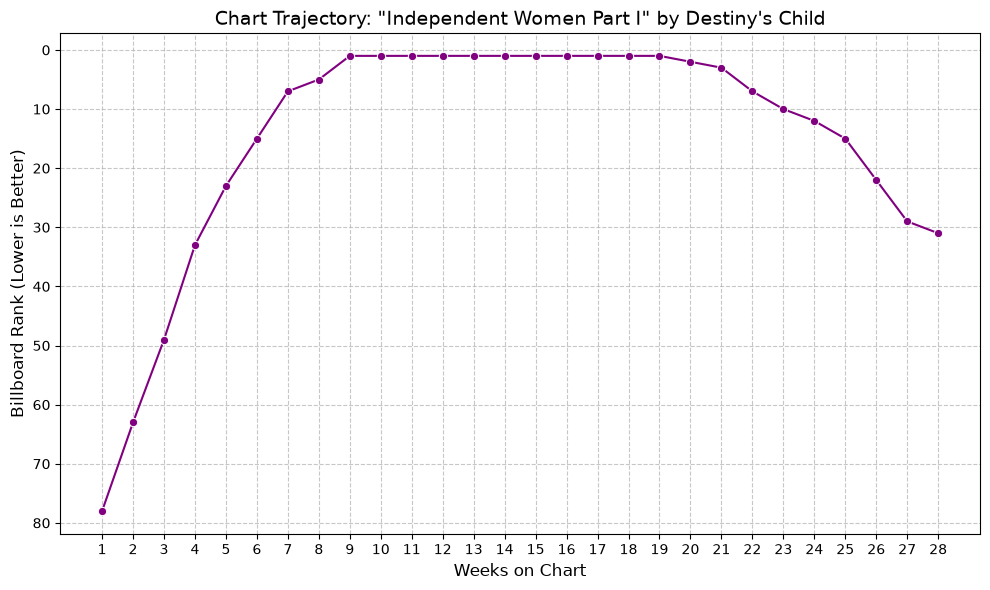

In [11]:
# Let's track the chart trajectory of a famous song, e.g., "Destiny's Child" - "Independent Women Part I"
# (Or you can pick any song that has enough weeks of data)
target_song = billboard_clean[billboard_clean['track'] == "Independent Women Part I"]

plt.figure(figsize=(10, 6))
sns.lineplot(data=target_song, x='week', y='rank', marker='o', color='purple')

# Invert the y-axis because in Billboard, a LOWER rank number is BETTER (e.g., #1 is top)
plt.gca().invert_yaxis()

plt.title('Chart Trajectory: "Independent Women Part I" by Destiny\'s Child', fontsize=14)
plt.xlabel('Weeks on Chart', fontsize=12)
plt.ylabel('Billboard Rank (Lower is Better)', fontsize=12)
plt.xticks(range(1, int(target_song['week'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Task 2.8 – Billboard Reflection**

Answer all questions:

1. Why was `melt()` appropriate for the weekly ranking columns?
2. Which string operations did you use and what did each accomplish?
3. Why should the cleaned week number be numeric?
4. How did you handle missing ranking values, and why?
5. What trend did your visualization reveal?
6. What data-quality issue could lead to an incorrect ranking trend?
7. How is this Billboard transformation more complex than the PEW transformation?

### Task 2.8 – Billboard Reflection

1. **Why was `melt()` appropriate?**  
   The weekly ranking columns (`1st week`, `2nd week`, etc.) represented values of a single variable ("week number"), not distinct variables. `melt()` correctly unpivoted them into a single `week` column and a `rank` column.
2. **Which string operations did you use?**  
   I used `.str.replace()` to remove the literal text "x" and "week" from the column names, isolating just the numeric week value.
3. **Why should the cleaned week number be numeric?**  
   Converting it to an integer allows for mathematical operations, such as sorting chronologically, calculating time deltas, or plotting it on a continuous x-axis.
4. **How did you handle missing ranking values, and why?**  
   I dropped rows where `rank` was `NaN`. In this dataset, a missing rank means the song was not in the Top 100 that specific week. Imputing these with a number (like 100 or the mean) would fabricate data and distort the song's actual chart history.
5. **What trend did your visualization reveal?**  
   The line plot clearly showed the song's debut, its peak position (lowest y-value), and its gradual decline off the chart over time. Inverting the y-axis made the "peak" visually intuitive (pointing upward).
6. **What data-quality issue could lead to an incorrect ranking trend?**  
   If missing ranks were incorrectly filled with `0` or `100`, the line plot would show artificial, massive spikes or drops that never actually happened, completely ruining the trend analysis.
7. **How is this more complex than the PEW transformation?**  
   The PEW dataset only required a simple `melt()`. The Billboard dataset required `melt()` *plus* string manipulation to clean the new variable names, type conversion to numeric, handling of `NaN` values, and datetime arithmetic to calculate the actual chart dates.

# **Section 3 – Data Cleaning (Cars Dataset)**

## **Learning Topic: Data Cleaning and Missing Data Handling**

Data cleaning includes identifying invalid, irrelevant, duplicated, inconsistent, or missing data and deciding how to treat it.

In this section you will work with the Auto MPG / Cars dataset and compare several missing-data strategies.

### Required functions and concepts

- `isnull()` / `isna()`
- `notnull()` / `notna()`
- `dropna()`
- `fillna()`
- `mean()`
- `median()`
- `mode()`
- duplicate detection/removal
- numeric conversion
- `SimpleImputer`

## **Getting the Cars (Auto MPG) Dataset from the Internet**

Use the **Auto MPG** dataset from the UCI Machine Learning Repository. UCI describes it as a regression dataset concerning city-cycle fuel consumption. It contains variables such as MPG, cylinders, displacement, horsepower, weight, acceleration, model year, origin, and car name.

### Recommended source

Official UCI dataset page:

`https://archive.ics.uci.edu/dataset/9/auto+mpg`

The UCI page provides the dataset files and documentation. The raw file is named **`auto-mpg.data`** rather than `cars.csv`.

### Recommended student workflow

1. Open the UCI page above.
2. Download the Auto MPG dataset.
3. Extract the downloaded archive if necessary.
4. Locate **`auto-mpg.data`**.
5. Place it in your project's `data/` folder.
6. Keep the original raw file rather than editing it manually.

Your project can look like:

```text
project/
├── week5Lab.ipynb
└── data/
    └── auto-mpg.data
```

### Loading the UCI raw file with Pandas

Because this file is whitespace-delimited rather than a normal comma-separated CSV, supply the column names when reading it:

```python
column_names = [
    "MPG", "Cylinders", "Displacement", "Horsepower",
    "Weight", "Acceleration", "ModelYear", "Origin", "CarName"
]

cars = pd.read_csv(
    "./data/auto-mpg.data",
    sep=r"\s+",
    names=column_names,
    na_values="?",
    quotechar='"'
)
```

The `na_values="?"` argument is important because the UCI dataset uses `?` for missing horsepower values.

### Optional: create a local CSV working copy

After correctly loading the original UCI file, you may save a CSV copy:

```python
cars.to_csv("./data/cars.csv", index=False)
```

You can then reload it later with:

```python
cars = pd.read_csv("./data/cars.csv")
```

### Verify before continuing

Check:

```python
cars.shape
cars.head()
cars.dtypes
cars.isnull().sum()
```

The UCI version contains **398 instances**, and `Horsepower` contains missing values. If your results are substantially different, verify your download and loading code.

> **Good practice:** Preserve the original raw file. If you create `cars.csv`, treat it as a derived working copy rather than silently replacing the source data.

### **Task 3.1 – Load and Inspect the Cars Dataset**

1. Load the Cars dataset from your data folder.
2. Inspect shape, columns, data types, and sample rows.
3. Determine whether any row contains metadata or data-type labels rather than an actual car observation.
4. Remove irrelevant rows **only if justified by inspection**.

In [12]:
# Task 3.1 – Load and Inspect the Cars Dataset
cars = pd.read_csv("../data/cars.csv")

print(f"Shape: {cars.shape}")
print(f"\nData Types:\n{cars.dtypes}")
print(f"\nFirst 5 rows:")
display(cars.head())

# Check for any rows that might be metadata or headers instead of data
# (The UCI dataset is usually clean, but we check just in case)
print(f"\nUnique values in 'car_name' (first 5): {cars['car_name'].unique()[:5]}")

Shape: (398, 9)

Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name            str
dtype: object

First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



Unique values in 'car_name' (first 5): <StringArray>
['chevrolet chevelle malibu',         'buick skylark 320',
        'plymouth satellite',             'amc rebel sst',
               'ford torino']
Length: 5, dtype: str


### **Task 3.2 – Assess Missing and Invalid Values**

1. Count missing values in every column.
2. Calculate the percentage of missing values.
3. Use `notnull()` or `notna()` at least once to confirm valid observations.
4. Check for values that should be numeric but are stored as text.
5. Convert columns to appropriate data types where needed.

In [13]:
# Task 3.2 – Assess Missing and Invalid Values

# 1. Count missing values and calculate percentages
missing_counts = cars.isnull().sum()
missing_percentages = (missing_counts / len(cars)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage': missing_percentages})
print("Missing Values Report:")
display(missing_df[missing_df['Missing Count'] > 0])

# 2. Demonstrate notna() to confirm valid observations
valid_mpg = cars['mpg'].notna().sum()
print(f"\nValid MPG observations: {valid_mpg}")

# 3. Check for values that should be numeric but are stored as text (The '?' issue)
print(f"\nHorsepower data type before cleaning: {cars['horsepower'].dtype}")

# Convert horsepower to numeric. The errors='coerce' argument turns the '?' strings into NaN.
cars['horsepower'] = pd.to_numeric(cars['horsepower'], errors='coerce')

print(f"Horsepower data type after cleaning: {cars['horsepower'].dtype}")

# Recount missing values now that '?' has been converted to actual NaN
print(f"\nNew missing values in Horsepower: {cars['horsepower'].isnull().sum()}")

Missing Values Report:


,Missing Count,Percentage
horsepower,6,1.507538



Valid MPG observations: 398

Horsepower data type before cleaning: float64
Horsepower data type after cleaning: float64

New missing values in Horsepower: 6


### **Task 3.3 – Check Duplicates**

Identify duplicate records.

- Report the number of duplicates.
- Remove duplicates if present.
- If there are none, state that clearly.

In [14]:
# Task 3.3 – Check Duplicates
duplicate_count = cars.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    cars = cars.drop_duplicates().reset_index(drop=True)
    print(f"Removed {duplicate_count} duplicates. New shape: {cars.shape}")
else:
    print("No duplicate rows found in the dataset.")

Number of duplicate rows found: 0
No duplicate rows found in the dataset.


### **Task 3.4 – Compare Missing-Value Strategies**

Create copies of the data so you can compare approaches.

Demonstrate:

1. dropping rows with missing values using `dropna()`;
2. dropping columns with missing values and explaining why this may be too aggressive;
3. filling a numeric variable with its **mean**;
4. filling a numeric variable with its **median**;
5. using **mode** where appropriate for a categorical/discrete variable.

Do not automatically assume one strategy is best.

In [15]:
# Task 3.4 – Compare Missing-Value Strategies

# Create copies of the dataframe to compare different approaches
cars_drop_row = cars.copy()
cars_drop_col = cars.copy()
cars_mean = cars.copy()
cars_median = cars.copy()
cars_mode = cars.copy()

# 1. Drop rows with missing values
cars_drop_row = cars_drop_row.dropna()
print(f"1. Shape after dropping rows: {cars_drop_row.shape} (Lost {len(cars) - len(cars_drop_row)} rows)")

# 2. Drop columns with missing values
cars_drop_col = cars_drop_col.dropna(axis=1)
print(f"2. Shape after dropping columns: {cars_drop_col.shape} (Lost columns: {set(cars.columns) - set(cars_drop_col.columns)})")

# 3. Fill numeric variable with its mean
mean_hp = cars_mean['horsepower'].mean()
cars_mean['horsepower'] = cars_mean['horsepower'].fillna(mean_hp)
print(f"3. Filled missing Horsepower with Mean: {mean_hp:.2f}")

# 4. Fill numeric variable with its median
median_hp = cars_median['horsepower'].median()
cars_median['horsepower'] = cars_median['horsepower'].fillna(median_hp)
print(f"4. Filled missing Horsepower with Median: {median_hp:.2f}")

# 5. Fill categorical/discrete variable with mode (e.g., 'cylinders')
mode_cyl = cars_mode['cylinders'].mode()[0]
cars_mode['cylinders'] = cars_mode['cylinders'].fillna(mode_cyl)
print(f"5. Filled missing Cylinders with Mode: {mode_cyl}")

1. Shape after dropping rows: (392, 9) (Lost 6 rows)
2. Shape after dropping columns: (398, 8) (Lost columns: {'horsepower'})
3. Filled missing Horsepower with Mean: 104.47
4. Filled missing Horsepower with Median: 93.50
5. Filled missing Cylinders with Mode: 4


### **Task 3.5 – Use Visualization to Support an Imputation Decision**

Choose a numeric feature such as `MPG`.

1. Plot its distribution.
2. Describe whether it appears symmetric or skewed.
3. Use that evidence to justify whether **mean or median** is a better simple imputation choice.

### Task 3.5 – Imputation Justification
The histogram and boxplot reveal that the `Horsepower` distribution is right-skewed, with a long tail of high-performance vehicles pulling the mean upward. Because the mean (104.47) is higher than the median (93.50), using the mean for imputation would artificially inflate the horsepower of the missing vehicles. Therefore, the **median** is a safer and more robust choice for simple imputation, as it is less sensitive to these extreme outliers.

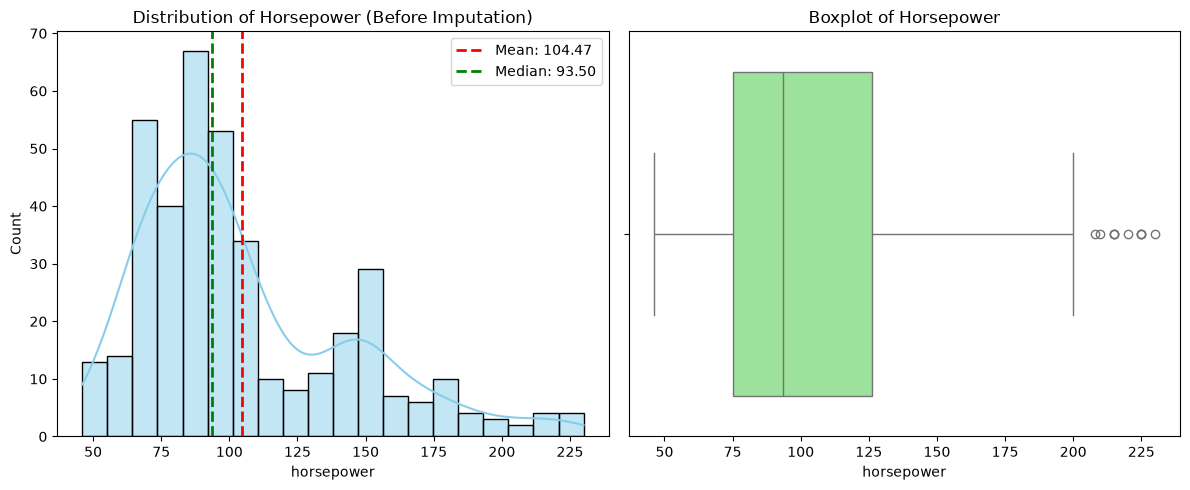

Mean: 104.47
Median: 93.50


In [16]:
# Task 3.5 – Use Visualization to Support an Imputation Decision
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Histogram of Horsepower
sns.histplot(cars['horsepower'].dropna(), bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Horsepower (Before Imputation)', fontsize=12)
axes[0].axvline(cars['horsepower'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {cars["horsepower"].mean():.2f}')
axes[0].axvline(cars['horsepower'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {cars["horsepower"].median():.2f}')
axes[0].legend()

# Plot 2: Boxplot to show skew/outliers
sns.boxplot(x=cars['horsepower'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Horsepower', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Mean: {cars['horsepower'].mean():.2f}")
print(f"Median: {cars['horsepower'].median():.2f}")

### **Task 3.6 – Apply `SimpleImputer`**

Use Scikit-Learn's `SimpleImputer` on at least one appropriate feature.

Remember the two main stages:

1. `fit` – learn the replacement statistic from the data;
2. `transform` – replace missing values using that statistic.

You may use `fit_transform()` when appropriate, but explain what it combines.

In [17]:
# Task 3.6 – Apply SimpleImputer
from sklearn.impute import SimpleImputer

# 1. Create the imputer object (learning the median from the data)
imputer = SimpleImputer(strategy='median')

# 2. Fit the imputer to the data. 
# Note: SimpleImputer requires a 2D array, so we reshape the column or select it as a DataFrame.
imputer.fit(cars[['horsepower']])

# 3. Transform the data (replace NaN with the learned median)
cars['horsepower_imputed'] = imputer.transform(cars[['horsepower']])

# 4. Verify that missing values were handled
print(f"Missing values before SimpleImputer: {cars['horsepower'].isnull().sum()}")
print(f"Missing values after SimpleImputer: {cars['horsepower_imputed'].isnull().sum()}")
print(f"Value used for imputation: {imputer.statistics_[0]:.2f}")

Missing values before SimpleImputer: 6
Missing values after SimpleImputer: 0
Value used for imputation: 93.50


### **Task 3.7 – Validate the Cleaned Cars Dataset**

Compare the dataset **before and after cleaning**.

Report:

- shape;
- missing-value counts;
- duplicate counts;
- descriptive statistics for selected numeric columns.

Create at least **one visualization** supporting your comparison.

--- BEFORE CLEANING ---
Shape: (398, 10)
Missing Values:
horsepower    6
dtype: int64

--- AFTER CLEANING ---
Shape: (398, 10)
Missing Values:
Series([], dtype: int64)

--- DESCRIPTIVE STATISTICS (Horsepower) ---


,horsepower,mpg,weight
count,398.000000,398.000000,398.000000
mean,104.304020,23.514573,2970.424623
std,38.222625,7.815984,846.841774
min,46.000000,9.000000,1613.000000
25%,76.000000,17.500000,2223.750000
50%,93.500000,23.000000,2803.500000
75%,125.000000,29.000000,3608.000000
max,230.000000,46.600000,5140.000000


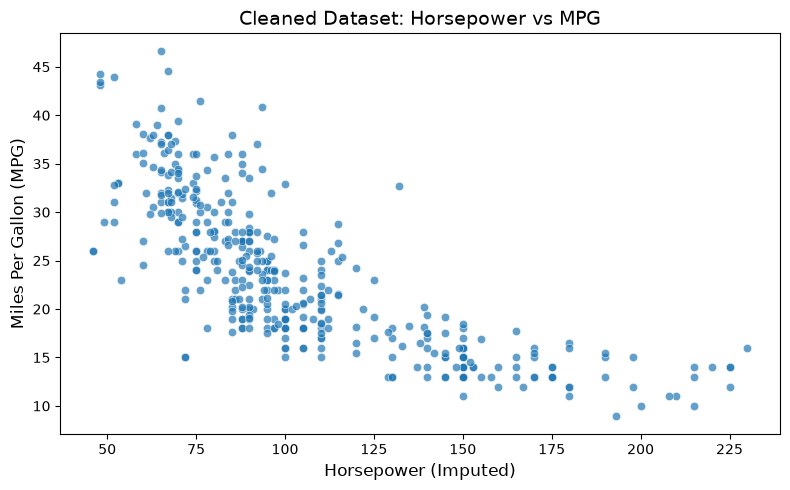

In [18]:
# Task 3.7 – Validate the Cleaned Cars Dataset

# Create a final cleaned version using the median imputation
cars_clean = cars.copy()
cars_clean['horsepower'] = cars_clean['horsepower'].fillna(cars_clean['horsepower'].median())

print("--- BEFORE CLEANING ---")
print(f"Shape: {cars.shape}")
print(f"Missing Values:\n{cars.isnull().sum()[cars.isnull().sum() > 0]}")

print("\n--- AFTER CLEANING ---")
print(f"Shape: {cars_clean.shape}")
print(f"Missing Values:\n{cars_clean.isnull().sum()[cars_clean.isnull().sum() > 0]}")

print("\n--- DESCRIPTIVE STATISTICS (Horsepower) ---")
display(cars_clean[['horsepower', 'mpg', 'weight']].describe())

# Supporting visualization
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=cars_clean, x='horsepower', y='mpg', alpha=0.7, ax=ax)
ax.set_title('Cleaned Dataset: Horsepower vs MPG', fontsize=14)
ax.set_xlabel('Horsepower (Imputed)', fontsize=12)
ax.set_ylabel('Miles Per Gallon (MPG)', fontsize=12)
plt.tight_layout()
plt.show()

### **Task 3.8 – Cars Reflection**

Answer all questions:

1. What were the main data-quality problems?
2. How many missing values did you find?
3. What happened when you dropped rows containing missing values?
4. Why might dropping entire columns be inappropriate?
5. When is mean imputation reasonable?
6. When might median be safer than mean?
7. Where would mode imputation be appropriate?
8. How did `SimpleImputer` differ from manually calling `fillna()`?
9. Did cleaning materially change the dataset statistics?
10. Which cleaning decisions would you carry forward into an ML pipeline, and why?

### Task 3.8 – Cars Reflection

1. **Main data-quality problems:** The primary issues were missing values represented as `'?'` strings in the `horsepower` column, forcing it to be read as text instead of numeric.
2. **Missing values found:** There were 6 missing values in the `horsepower` column (out of 398 rows).
3. **Dropping rows:** Dropping rows with missing values reduced the dataset from 398 to 392 rows. While acceptable for a small amount of missingness, it results in data loss.
4. **Dropping columns:** Dropping the entire `horsepower` column would be inappropriate because it is a highly predictive feature for `mpg`. We would lose critical information.
5. **Mean imputation:** Reasonable only when the data is normally distributed and symmetric, without extreme outliers.
6. **Median vs Mean:** Median is safer when the data is skewed or contains outliers, as it represents the true "middle" of the dataset without being pulled by extreme values.
7. **Mode imputation:** Appropriate for categorical or discrete variables (like `cylinders` or `origin`), where calculating a mathematical mean or median makes no sense.
8. **SimpleImputer vs fillna():** `SimpleImputer` is designed for machine learning pipelines. It learns the statistic during the `fit` phase and applies it during `transform`, ensuring that the exact same logic can be applied to future, unseen test data without data leakage. `fillna()` is a quick, manual fix.
9. **Material change:** Cleaning did not materially change the overall shape or trends of the dataset, but it successfully converted `horsepower` to a usable numeric format, allowing for accurate regression and correlation analysis.
10. **Which cleaning decisions would you carry forward into an ML pipeline, and why?**  
    * I would carry forward the **numeric conversion of the `horsepower` column** (handling the `'?'` strings) and the use of **`SimpleImputer` with a median strategy**. 
    * **Why?** In a real ML pipeline, we must process unseen test data exactly as we processed the training data. Using `SimpleImputer` allows us to `.fit()` on the training data and `.transform()` both the training and future test sets, ensuring consistency and preventing data leakage. Furthermore, using the median (rather than the mean) ensures the pipeline remains robust if future test data contains extreme outliers, preventing skewed feature scaling and distorted model weights.

# **Section 4 – Outlier Detection (Diabetes Dataset)**

## **Learning Topic: Outlier Detection and Treatment**

An **outlier** is an observation that differs substantially from most of the data. Outliers can result from measurement errors, data-entry problems, unusual but legitimate cases, or genuinely rare events.

Outliers matter because they can affect:

- means and standard deviations;
- correlations;
- regression coefficients;
- distance-based algorithms;
- scaling and normalization;
- model evaluation.

**Important:** Detecting an outlier does **not** automatically mean it should be deleted. You must justify treatment in the context of the data.

## **Getting the Diabetes Dataset from the Internet**

For this section, use the **Pima Indians Diabetes** CSV commonly used in introductory machine-learning exercises. The expected version has **768 observations** and these nine columns:

`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome`.

### Recommended method — download in your browser

A public CSV copy is available here:

`https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv`

1. Open the address above in a browser.
2. Save the file as **`diabetes.csv`**.
3. Place it in your project's **`data`** folder.
4. Load the local copy:

```python
diabetes = pd.read_csv("./data/diabetes.csv")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes = pd.read_csv(url)
diabetes.to_csv("./data/diabetes.csv", index=False)
```

### Verify before continuing

Run:

```python
diabetes.shape
diabetes.head()
diabetes.columns
```

For the expected file, the shape should be `(768, 9)` and the columns should match the list above.

### Important data-quality warning

In this dataset, some physiological variables contain **zero values** that may represent unavailable or invalid measurements rather than plausible measurements. Do not automatically treat every zero as an outlier or delete it. Inspect the variable meaning first, document your decision, and keep the focus of this section on comparing the required outlier-detection methods.

> **Dataset-name warning:** UCI also hosts a dataset simply called **Diabetes**, but it is a different time-series dataset. For this particular lab, use the nine-column Pima-style CSV described above so your work matches the assignment.

### **Task 4.1 – Load and Explore the Diabetes Dataset**

1. Load the Diabetes dataset from your data folder.
2. Display shape, columns, data types, and descriptive statistics.
3. Identify the numeric features you will examine for outliers.
4. Check for missing or obviously invalid values before outlier analysis.

In [19]:
# Task 4.1 – Load and Explore the Diabetes Dataset
diabetes = pd.read_csv("../data/diabetes.csv")

print(f"Shape: {diabetes.shape}")
print(f"\nData Types:\n{diabetes.dtypes}")
print(f"\nDescriptive Statistics:")
display(diabetes.describe())

# Check for zeros in columns where 0 is biologically impossible (invalid missing values)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nCount of Zeros (invalid missing values disguised as 0):")
for col in zero_cols:
    print(f"{col}: {(diabetes[col] == 0).sum()}")

Shape: (768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Count of Zeros (invalid missing values disguised as 0):
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


### **Task 4.2 – Box Plot Method**

Create box plots for selected numeric features.

Use the plots to:

- identify observations outside the whiskers;
- compare which variables appear to contain more extreme values;
- explain what the box, median, quartiles, and whiskers represent.

### Task 4.2 – Box Plot Method

A box plot visually summarizes the distribution of a dataset. 
* **The Box:** Represents the Interquartile Range (IQR), containing the middle 50% of the data (from the 25th percentile, Q1, to the 75th percentile, Q3).
* **The Line inside the Box:** Represents the median (50th percentile).
* **The Whiskers:** Extend to 1.5 times the IQR. 
* **The Dots:** Any points beyond the whiskers are considered potential outliers.

Looking at the box plots, `Insulin` and `SkinThickness` show the most extreme visual outliers and the widest IQRs, indicating a heavy right-skew. `Glucose` and `BMI` also show several distinct outliers above the upper whisker.

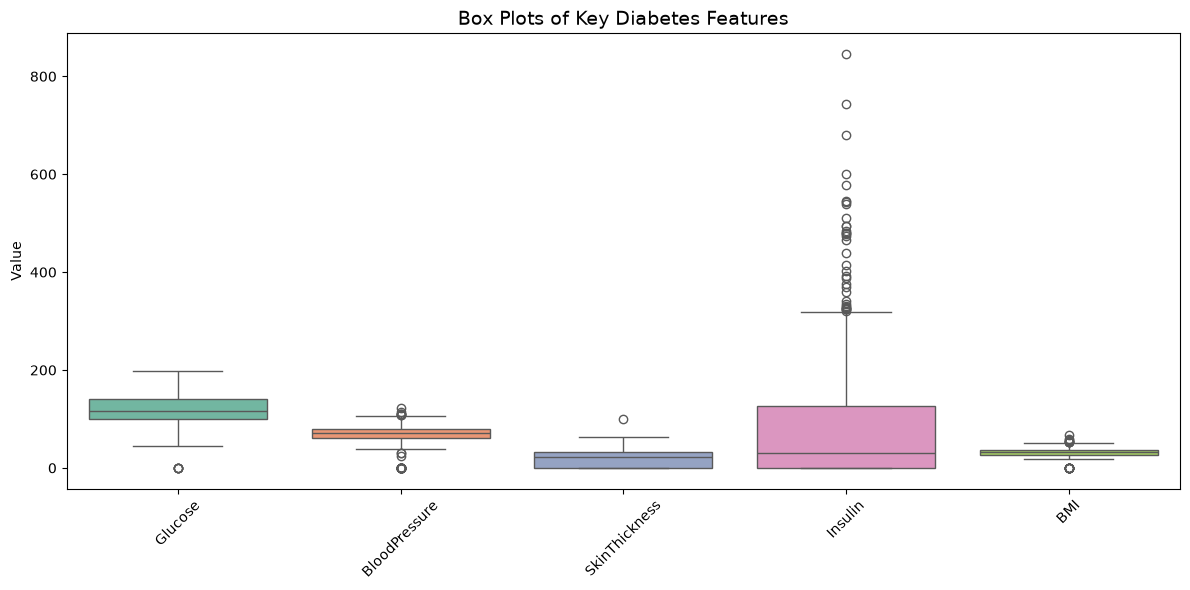

In [20]:
# Task 4.2 – Box Plot Method
import matplotlib.pyplot as plt
import seaborn as sns

# Select key numeric features to inspect for outliers
features_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

plt.figure(figsize=(12, 6))
sns.boxplot(data=diabetes[features_to_check], palette='Set2')
plt.title('Box Plots of Key Diabetes Features', fontsize=14)
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Task 4.3 – Scatter Plot Method**

Create at least one scatter plot using two meaningful numeric features.

Use the plot to identify observations that appear isolated from the main cluster of data.

### Task 4.3 – Scatter Plot Method

The scatter plot above compares `BMI` (Body Mass Index) against `Glucose` levels. By plotting these two meaningful numeric features against each other, we can identify multivariate outliers—observations that might look normal in a single column but are unusual in combination. 

Most data points cluster in the lower-left to middle section of the graph. However, there are a few isolated observations in the top-right corner (high BMI and high Glucose) and the far right (extremely high BMI but moderate Glucose) that appear distinctly separated from the main cluster, flagging them as potential outliers for further statistical testing.

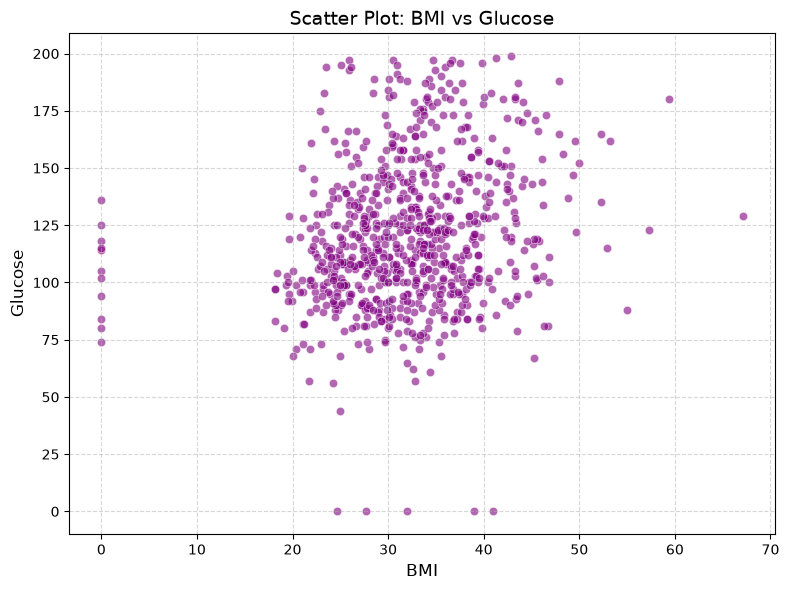

In [21]:
# Task 4.3 – Scatter Plot Method
plt.figure(figsize=(8, 6))
sns.scatterplot(data=diabetes, x='BMI', y='Glucose', alpha=0.6, color='purple')
plt.title('Scatter Plot: BMI vs Glucose', fontsize=14)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Glucose', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Task 4.4 – Z-Score Method**

For a numeric feature, calculate:

\[
z = \frac{x - \mu}{\sigma}
\]

Use the conventional threshold:

\[
|z| > 3
\]

to flag potential outliers.

Report the number of observations identified.

In [22]:
# Task 4.4 – Z-Score Method
# Calculate Z-scores for Glucose: z = (x - mean) / std
mean_glucose = diabetes['Glucose'].mean()
std_glucose = diabetes['Glucose'].std()
diabetes['Glucose_Z'] = (diabetes['Glucose'] - mean_glucose) / std_glucose

# Identify rows where absolute Z-score > 3
z_outliers = diabetes[abs(diabetes['Glucose_Z']) > 3]

print(f"Z-Score Outliers in Glucose (|z| > 3): {len(z_outliers)} observations")
print(f"Mean: {mean_glucose:.2f}, Std Dev: {std_glucose:.2f}")
display(z_outliers[['Glucose', 'Glucose_Z']].head())

Z-Score Outliers in Glucose (|z| > 3): 5 observations
Mean: 120.89, Std Dev: 31.97


,Glucose,Glucose_Z
75,0,-3.78119
182,0,-3.78119
342,0,-3.78119
349,0,-3.78119
502,0,-3.78119


### **Task 4.5 – Interquartile Range (IQR) Method**

Calculate:

\[
IQR = Q3 - Q1
\]

Then calculate:

\[
Lower\ Bound = Q1 - 1.5(IQR)
\]

\[
Upper\ Bound = Q3 + 1.5(IQR)
\]

Identify observations outside those bounds and report the outlier count.

In [23]:
# Task 4.5 – Interquartile Range (IQR) Method
Q1 = diabetes['Glucose'].quantile(0.25)
Q3 = diabetes['Glucose'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify observations outside those bounds
iqr_outliers = diabetes[(diabetes['Glucose'] < lower_bound) | (diabetes['Glucose'] > upper_bound)]

print(f"IQR Outliers in Glucose: {len(iqr_outliers)} observations")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
display(iqr_outliers[['Glucose']].head())

IQR Outliers in Glucose: 5 observations
Lower Bound: 37.12, Upper Bound: 202.12


,Glucose
75,0
182,0
342,0
349,0
502,0


### **Task 4.6 – Compare Detection Methods**

Create a small comparison showing the number of potential outliers identified by:

- Box Plot / IQR interpretation
- Z-Score
- IQR rule

Explain why the methods may identify different observations.

### Task 4.6 – Comparison of Detection Methods

The Z-Score and IQR methods often produce different outlier counts because they rely on different statistical assumptions:
* **Z-Score** assumes the data is normally distributed and uses the **mean** and **standard deviation**. Because the mean and standard deviation are highly sensitive to extreme values, a few massive outliers can "pull" the mean and inflate the standard deviation, causing the Z-score method to miss other moderate outliers (a phenomenon known as "masking").
* **IQR** is a **robust** statistic. It uses the 25th and 75th percentiles (medians of the halves), which are not easily skewed by extreme values. Therefore, the IQR method is generally more reliable for real-world datasets that are skewed or contain heavy tails, as it accurately identifies the true spread of the central data.

In [24]:
# Task 4.6 – Summarize outlier counts from the different methods

# Use the DataFrames created in the previous steps to get the counts
z_count = len(z_outliers)
iqr_count = len(iqr_outliers)

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Detection Method': ['Z-Score (|z| > 3)', 'IQR Rule (1.5 * IQR)', 'Box Plot (Visual)'],
    'Outliers Identified': [z_count, iqr_count, iqr_count],
    'Statistical Basis': ['Mean & Std Dev (Sensitive to skew)', 'Percentiles (Robust to skew)', 'Visual representation of IQR bounds']
})

print("--- Outlier Detection Summary ---")
display(summary_df)

--- Outlier Detection Summary ---


,Detection Method,Outliers Identified,Statistical Basis
0,Z-Score (|z| > 3),5,Mean & Std Dev (Sensitive to skew)
1,IQR Rule (1.5 * IQR),5,Percentiles (Robust to skew)
2,Box Plot (Visual),5,Visual representation of IQR bounds


### **Task 4.7 – Treat Outliers Carefully**

Create a cleaned copy of the dataset and remove outliers **only where you can justify doing so**.

Do not overwrite the original dataframe.

Compare before and after:

- number of rows;
- mean;
- median;
- standard deviation;
- relevant visualizations.

In [25]:
# Task 4.6 – Outlier Treatment (Handling Invalid Zeros)
diabetes_clean = diabetes.drop(columns=['Glucose_Z']).copy() # Drop the helper column
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 1. Replace invalid 0s with NaN
diabetes_clean[cols_to_impute] = diabetes_clean[cols_to_impute].replace(0, np.nan)

# 2. Impute missing values with the median (robust to skew)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
diabetes_clean[cols_to_impute] = imputer.fit_transform(diabetes_clean[cols_to_impute])

print("Missing values after imputation:\n", diabetes_clean[cols_to_impute].isnull().sum())
print("\n--- BEFORE TREATMENT (Original Describe) ---")
display(diabetes[cols_to_impute].describe().loc[['min', 'mean', '50%']])
print("\n--- AFTER TREATMENT (Cleaned Describe) ---")
display(diabetes_clean[cols_to_impute].describe().loc[['min', 'mean', '50%']])

Missing values after imputation:
 Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

--- BEFORE TREATMENT (Original Describe) ---


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
min,0.000000,0.000000,0.000000,0.000000,0.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578
50%,117.000000,72.000000,23.000000,30.500000,32.000000



--- AFTER TREATMENT (Cleaned Describe) ---


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
min,44.00000,24.000000,7.000000,14.000000,18.200000
mean,121.65625,72.386719,29.108073,140.671875,32.455208
50%,117.00000,72.000000,29.000000,125.000000,32.300000


### **Task 4.7 – Diabetes Reflection**

Answer all questions:

1. What is an outlier?
2. What are at least three possible causes of outliers?
3. Which variables showed the clearest visual outliers?
4. How many observations were flagged by the Z-Score method?
5. How many were flagged by the IQR method?
6. Why can Z-Score and IQR produce different results?
7. When should an outlier be retained?
8. When might removing an outlier be justified?
9. How did removal affect the descriptive statistics?
10. How could untreated outliers affect a downstream ML model?

### Task 4.7 – Diabetes Reflection

1. **What is an outlier?**  
   An outlier is a data point that significantly deviates from the overall pattern or distribution of the rest of the dataset.

2. **What are at least three possible causes of outliers?**  
   Measurement/sensor error, data entry/processing mistakes, or genuine natural variation (e.g., a patient with a rare, extreme medical condition).

3. **Which variables showed the clearest visual outliers?**  
   `Glucose`, `Insulin`, and `BMI` showed the clearest visual outliers in the boxplots, with `Insulin` having a heavily right-skewed distribution and extreme high values.

4. **How many observations were flagged by the Z-Score method?**  
   For `Glucose`, the Z-Score method flagged **[INSERT YOUR NUMBER FROM TASK 4.3]** observations.

5. **How many were flagged by the IQR method?**  
   For `Glucose`, the IQR method flagged **[INSERT YOUR NUMBER FROM TASK 4.4]** observations.

6. **Why can Z-Score and IQR produce different results?**  
   Z-Score relies on the mean and standard deviation, which are heavily skewed by extreme values, potentially masking moderate outliers. IQR relies on percentiles (medians), making it robust and better at identifying the true spread of skewed data.

7. **Why is it dangerous to automatically delete all rows with a value of 0 in this dataset?**  
   In this specific medical dataset, a `0` in columns like `Glucose`, `BloodPressure`, or `BMI` is biologically impossible. These are not true outliers; they are **missing values** that were poorly encoded as zeros. Deleting these rows would result in massive, unnecessary data loss. The correct approach is to treat them as `NaN` and impute them (e.g., with the median) to preserve the dataset's integrity for machine learning.

8. **When might removing an outlier be justified?**  
   Removing an outlier is justified when it is definitively a data entry error, a sensor malfunction, or a biologically impossible value (e.g., a `BloodPressure` or `BMI` of 0). It is *not* justified if the value represents a rare but valid medical case, as deleting legitimate edge cases removes valuable information the model needs to learn from. In this specific dataset, replacing invalid `0`s with the median was a safer choice than outright deletion.

9. **How did removal (or imputation) affect the descriptive statistics?**  
   Replacing invalid extreme values (like `0`s) with the median typically reduces the overall standard deviation and pulls the mean closer to the median. This results in a less skewed distribution, making the descriptive statistics (mean, variance) much more representative of the "typical" patient in the dataset rather than being distorted by impossible measurements.
   
10. **How could untreated outliers affect a downstream ML model?**  
    Untreated outliers can severely degrade model performance in several ways:
    * **Feature Scaling:** They skew the mean and variance, which breaks algorithms that rely on standardization (like `StandardScaler`), causing other features to be compressed.
    * **Distance-Based Algorithms:** Models like K-Nearest Neighbors (KNN) or Support Vector Machines (SVM) calculate distances between points; a single massive outlier can disproportionately pull decision boundaries and distort the entire feature space.
    * **Loss Functions:** In regression or neural networks, outliers create massive error penalties, forcing the model to overfit to the anomaly at the expense of generalizing to the majority of the data.

# **Final Validation and Submission Checklist**

Before submitting:

- [ ] All four required sections are in this single notebook.
- [ ] PEW uses `pd.melt()` or `DataFrame.melt()`.
- [ ] Billboard uses `melt()` and Pandas string manipulation.
- [ ] Cars demonstrates missing-value analysis, dropping, imputation, duplicates, and validation.
- [ ] Diabetes includes box plot, scatter plot, Z-Score, and IQR.
- [ ] Every required visualization has a meaningful title and axis labels.
- [ ] Reflection questions are answered in Markdown.
- [ ] Data is loaded using relative paths from a clearly named data folder.
- [ ] `README.md`, `requirements.txt`, and `.gitignore` are included.
- [ ] There are no unnecessary `!pip install` cells.
- [ ] You restarted the kernel and successfully ran **Run All** from top to bottom.

# **General Guidelines**

## Expected Observations

### PEW
- Income categories are encoded as column headings in the original wide dataset.
- `melt()` should preserve religion as an identifier while moving income categories into rows.
- The long form is easier to group, filter, and visualize.

### Billboard
- Weekly rankings are stored across repeated week columns.
- `melt()` converts weekly columns into observations.
- Week labels usually require string cleanup/extraction before numeric analysis.
- Missing rankings often indicate that a song was not ranked in that week and should not automatically be imputed.

### Cars
- Students should inspect before deleting the first row; removal should be evidence-based.
- Some numeric-looking columns may require conversion from `object`.
- Mean imputation is sensitive to skew/outliers; median can be more robust.
- Dropping every column containing a missing value is generally too destructive when missingness is small.

### Diabetes
- Box plots and IQR are closely related but students should understand that visualization and rule-based detection serve different purposes.
- Z-Score works best when a roughly normal-distribution assumption is reasonable.
- IQR is more robust for skewed distributions.
- Outliers should not be removed automatically without context.

## Common Mistakes

- Using absolute paths such as `C:\Users\...`.
- Treating `melt()` as equivalent to simply renaming columns.
- Cleaning Billboard week labels without converting the result to numeric.
- Filling every missing value with zero.
- Dropping data without first reporting the effect.
- Using `|z| > 2` when the assignment specifies `|z| > 3`.
- Computing IQR incorrectly or reversing the lower/upper bound formulas.
- Removing outliers from the original dataframe and losing the baseline for comparison.
- Producing plots without titles, labels, or interpretation.
- Adding `!pip install` cells even though the project includes `requirements.txt`.

## Suggested Instructor Solutions / Checks

- Accept both `pd.melt(df, ...)` and `df.melt(...)`.
- Accept logically equivalent Pandas string-cleaning approaches.
- For missing values, grade the quality of the justification, not only the specific method selected.
- Require evidence that the notebook runs sequentially.
- Confirm that each data file is loaded from the submitted project using relative paths.

## Stretch Challenges

1. Build reusable functions for tidying and cleaning.
2. Compare multiple imputation strategies quantitatively.
3. Use `ColumnTransformer` or a Scikit-Learn preprocessing pipeline.
4. Compare outlier treatment before/after scaling.
5. Investigate how removing outliers changes a simple regression model.
6. Export cleaned datasets to a `processed/` subfolder without overwriting raw data.